<a href="https://colab.research.google.com/github/moonbang2/capital/blob/byungdu/capital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_credit_default_risk_path = kagglehub.competition_download('home-credit-default-risk')

print('Data source import complete.')


홈 크레딧 채무 불이행

주제 신용 리스크 관리

기획
많은 사람들이 신용 이력이 부족하거나 아예 없어서 대출을 받는 데 어려움을 겪습니다. 그리고 안타깝게도, 이러한 사람들은 신뢰할 수 없는 대출업자들에게 이용당하는 경우가 많습니다.

안전하고 긍정적인 대출 경험을 제공함으로써 금융 소외 계층의 금융 접근성을 확대하고자 노력합니다. 이러한 소외 계층이 만족스러운 대출 경험을 누릴 수 있도록, 홈 크레딧은 통신 및 거래 정보 등 다양한 대체 데이터를 활용하여 고객의 상환 능력을 예측합니다

목표
고객이 성공적으로 상환할 수 있도록 원금, 만기, 상환 일정 등을 고려한 대출을 제공

* 원금
* 만기
* 상환 일정


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/home-credit-default-risk/sample_submission.csv
/kaggle/input/home-credit-default-risk/bureau_balance.csv
/kaggle/input/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/home-credit-default-risk/application_train.csv
/kaggle/input/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/home-credit-default-risk/application_test.csv
/kaggle/input/home-credit-default-risk/previous_application.csv
/kaggle/input/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/home-credit-default-risk/installments_payments.csv
/kaggle/input/home-credit-default-risk/bureau.csv


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
app_train = pd.read_csv('/kaggle/input/home-credit-default-risk/application_train.csv')
print('Training data shape: ', app_train.shape)
app_train.head()

prev_app = pd.read_csv('/kaggle/input/home-credit-default-risk/previous_application.csv')
print('\nPrevious application data shape: ', prev_app.shape)

pos_cash_balance = pd.read_csv('/kaggle/input/home-credit-default-risk/POS_CASH_balance.csv')
print('\nPOS Cash Balance data shape: ', pos_cash_balance.shape)

bureau = pd.read_csv('/kaggle/input/home-credit-default-risk/bureau.csv')
print('Bureau data shape:', bureau.shape)

bureau_balance = pd.read_csv('/kaggle/input/home-credit-default-risk/bureau_balance.csv')
print('Bureau Balance data shape:', bureau_balance.shape)

installments = pd.read_csv('/kaggle/input/home-credit-default-risk/installments_payments.csv')
print('Installments Payments data shape:', installments.shape)

credit_card = pd.read_csv('/kaggle/input/home-credit-default-risk/credit_card_balance.csv')
print('Credit Card Balance data shape:', credit_card.shape)

Training data shape:  (307511, 122)

Previous application data shape:  (1670214, 37)

POS Cash Balance data shape:  (10001358, 8)
Bureau data shape: (1716428, 17)
Bureau Balance data shape: (27299925, 3)
Installments Payments data shape: (13605401, 8)
Credit Card Balance data shape: (3840312, 23)


In [ ]:
print("App:",app_train.columns)
print("prev_app:",prev_app.columns)
print("pos_cash_balance:",pos_cash_balance.columns)
print("bureau:",bureau.columns)
print("bureau_balance:",bureau_balance.columns)
print("installments:",installments.columns)
print("credit_card:",credit_card.columns)

App: Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)
prev_app: Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE',
       'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE',
   

In [ ]:
import pandas as pd

# 1. 원천 데이터 로드
app_train = pd.read_csv('/kaggle/input/home-credit-default-risk/application_train.csv')[['SK_ID_CURR', 'TARGET', 'AMT_CREDIT', 'AMT_ANNUITY', 'FLAG_OWN_CAR', 'DAYS_BIRTH']]
prev_app = pd.read_csv('/kaggle/input/home-credit-default-risk/previous_application.csv')[['SK_ID_CURR', 'CNT_PAYMENT', 'NAME_CONTRACT_STATUS']]
installments = pd.read_csv('/kaggle/input/home-credit-default-risk/installments_payments.csv')

# 2. 상환 일정 준수 현황 집계 (상환 일정 분석)
installments['delay'] = (installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']).clip(lower=0)
ins_agg = installments.groupby('SK_ID_CURR').agg({
    'delay': 'mean',                   # 평균 지연 일수
    'AMT_INSTALMENT': 'mean',          # 회차별 평균 원리금
    'NUM_INSTALMENT_NUMBER': 'max'     # 현재까지 진행된 회차
}).reset_index()

# 3. 데이터 마트 통합 (원금, 만기 정보 결합)
df = pd.merge(app_train, ins_agg, on='SK_ID_CURR', how='left')
df = pd.merge(df, prev_app.groupby('SK_ID_CURR')['CNT_PAYMENT'].max().reset_index(), on='SK_ID_CURR', how='left')

# 결측치 처리
df['CNT_PAYMENT'] = df['CNT_PAYMENT'].fillna(df['CNT_PAYMENT'].median())
df = df.fillna(0)

In [ ]:
df.head()

,SK_ID_CURR,TARGET,AMT_CREDIT,AMT_ANNUITY,FLAG_OWN_CAR,DAYS_BIRTH,delay,AMT_INSTALMENT,NUM_INSTALMENT_NUMBER,CNT_PAYMENT
0,100002,1,406597.5,24700.5,N,-9461,0.000000,11559.247105,19.0,24.0
1,100003,0,1293502.5,35698.5,N,-16765,0.000000,64754.586000,12.0,12.0
2,100004,0,135000.0,6750.0,Y,-19046,0.000000,7096.155000,3.0,4.0
3,100006,0,312682.5,29686.5,N,-19005,0.000000,62947.088438,10.0,48.0
4,100007,0,513000.0,21865.5,N,-19932,0.954545,12666.444545,17.0,48.0


/tmp/ipykernel_55/692979152.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='credit_bin', y='TARGET', data=df, palette='OrRd')


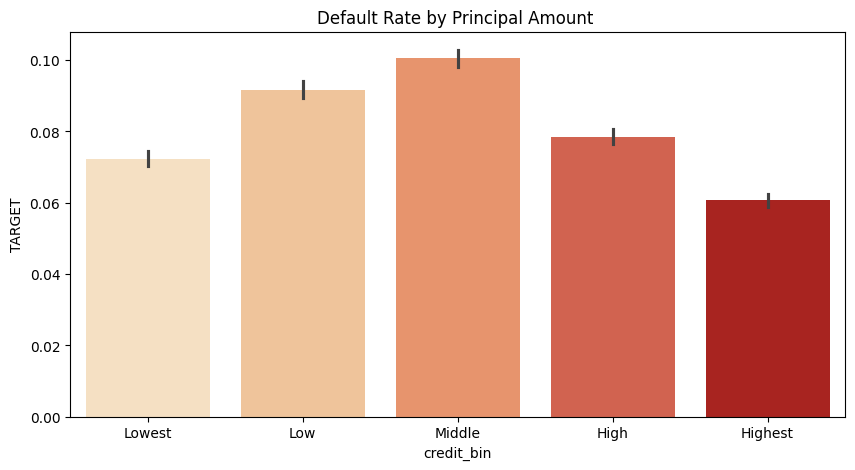

In [ ]:
# 원금(AMT_CREDIT)을 5개 구간으로 나눔
df['credit_bin'] = pd.qcut(df['AMT_CREDIT'], 5, labels=['Lowest', 'Low', 'Middle', 'High', 'Highest'])

plt.figure(figsize=(10, 5))
sns.barplot(x='credit_bin', y='TARGET', data=df, palette='OrRd')
plt.title('Default Rate by Principal Amount ')
plt.show()

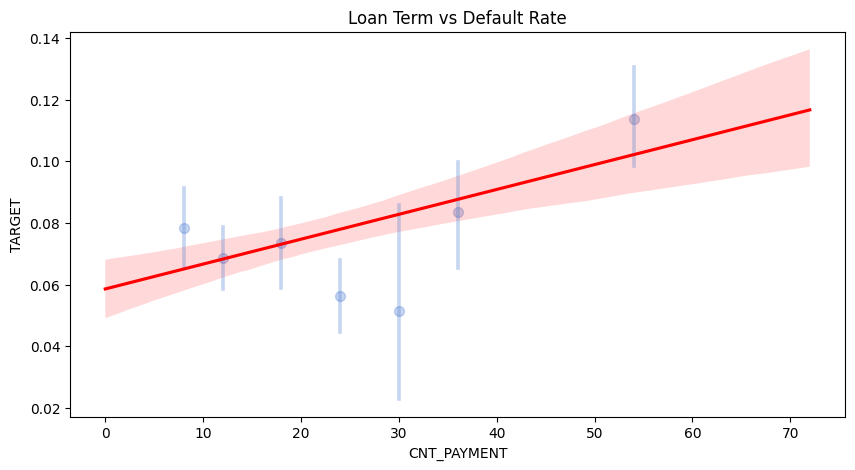

In [ ]:
# 만기(CNT_PAYMENT) 구간별 연체율 분석
plt.figure(figsize=(10, 5))
sns.regplot(x='CNT_PAYMENT', y='TARGET', data=df.sample(10000), x_bins=10, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Loan Term vs Default Rate')
plt.show()

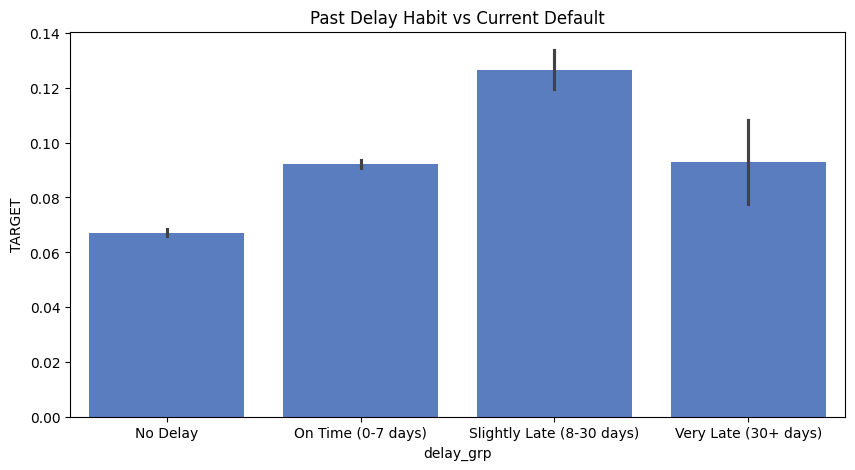

In [ ]:
# 평균 지연 일수(avg_delay) 구간별 현재 부도율
df['delay_grp'] = pd.cut(df['delay'], bins=[-1, 0, 5, 30, 1000], labels=['No Delay', 'On Time (0-7 days)', 'Slightly Late (8-30 days)', 'Very Late (30+ days)'])

plt.figure(figsize=(10, 5))
sns.barplot(x='delay_grp', y='TARGET', data=df)
plt.title('Past Delay Habit vs Current Default')
plt.show()

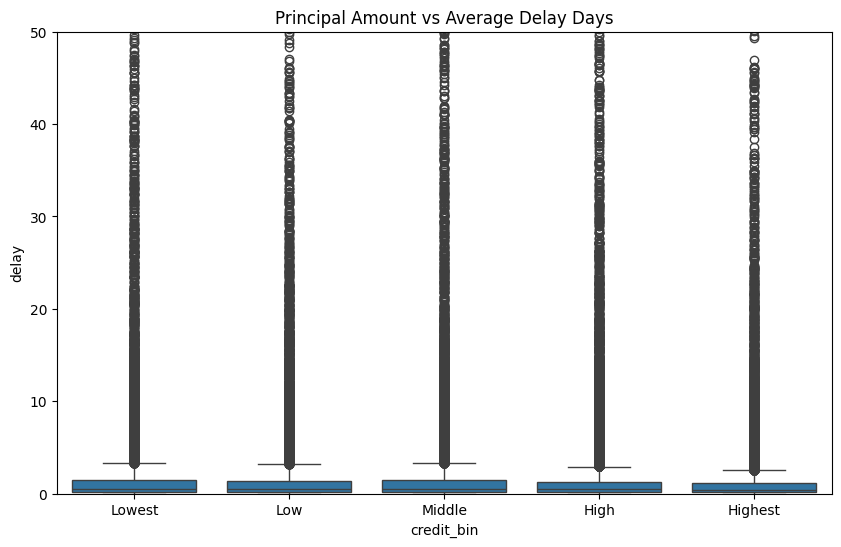

In [ ]:
# 원금 규모별 평균 연체 일수 분석
plt.figure(figsize=(10, 6))
sns.boxplot(x='credit_bin', y='delay', data=df[df['delay'] > 0]) # 연체 경험자만 추출
plt.ylim(0, 50) # 너무 큰 이상치는 제외하고 관찰
plt.title('Principal Amount vs Average Delay Days')
plt.show()

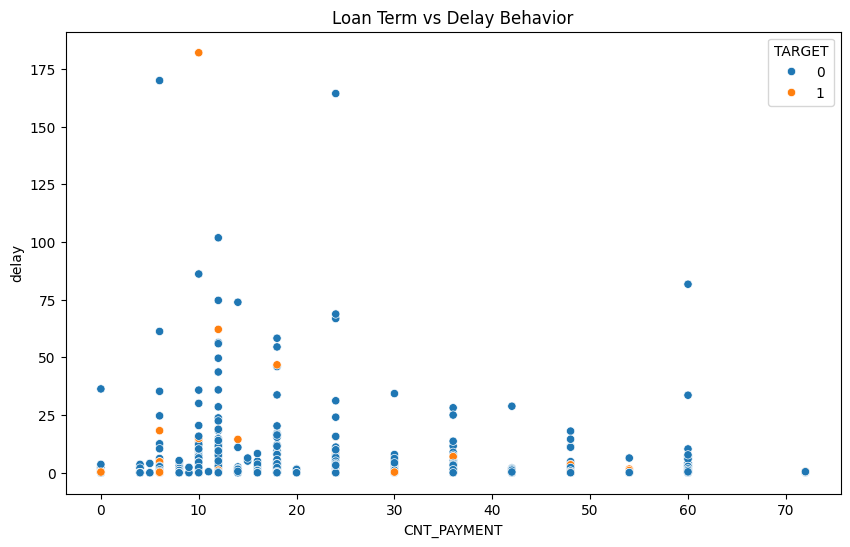

In [ ]:
# 만기(CNT_PAYMENT)와 연체율의 상관관계 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CNT_PAYMENT', y='delay', hue='TARGET', data=df.sample(5000))
plt.title('Loan Term vs Delay Behavior')
plt.show()

In [ ]:

# 1. Bureau(타사 정보)에서 연체 이력 추출
bureau['has_outer_overdue'] = (bureau['CREDIT_DAY_OVERDUE'] > 0).astype(int)
bureau_agg = bureau.groupby('SK_ID_CURR')['has_outer_overdue'].max().reset_index()

# 2. 기존 데이터와 결합 (fillna(0)를 여기서 바로 하지 않습니다)
chart3_data = df.merge(bureau_agg, on='SK_ID_CURR', how='left')

# 3. 범주형 변수를 제외하고 '수치형 변수'만 골라서 결측치 채우기
# 타사 정보가 없는 경우 연체가 없는 것(0)으로 간주합니다.
chart3_data['has_outer_overdue'] = chart3_data['has_outer_overdue'].fillna(0)

# 만약 다른 수치형 변수들도 있다면 아래와 같이 안전하게 채울 수 있습니다.
# num_cols = chart3_data.select_dtypes(include=['number']).columns
# chart3_data[num_cols] = chart3_data[num_cols].fillna(0)

print("데이터 결합 및 결측치 처리 완료!")

데이터 결합 및 결측치 처리 완료!


/tmp/ipykernel_55/4076658329.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='has_outer_overdue', y='TARGET', data=chart3_data, palette='coolwarm')


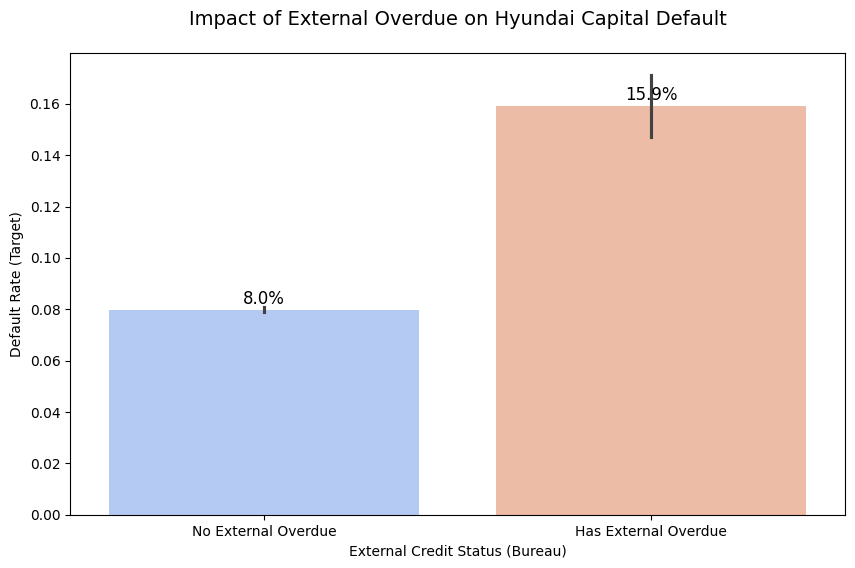

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 시각화 설정
plt.style.use('seaborn-v0_8-muted') # 깔끔한 테마 설정
plt.figure(figsize=(10, 6))

# 타사 연체 여부별 자사 부도율(TARGET) 분석
sns.barplot(x='has_outer_overdue', y='TARGET', data=chart3_data, palette='coolwarm')

plt.title('Impact of External Overdue', fontsize=14, pad=20)
plt.xticks([0, 1], ['No External Overdue', 'Has External Overdue'])
plt.ylabel('Default Rate (Target)')
plt.xlabel('External Credit Status (Bureau)')

# 부도율 수치 표시
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 8),
                textcoords='offset points')

plt.show()

In [ ]:
chart3_data.columns

Index(['SK_ID_CURR', 'TARGET', 'AMT_CREDIT', 'AMT_ANNUITY', 'FLAG_OWN_CAR',
       'DAYS_BIRTH', 'delay', 'AMT_INSTALMENT', 'NUM_INSTALMENT_NUMBER',
       'CNT_PAYMENT', 'credit_bin', 'delay_grp', 'has_outer_overdue'],
      dtype='object')

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

# 1. 학습용 변수 선택 (수치형으로 변환된 데이터 사용)
# delay_category는 모델 학습을 위해 Label Encoding 또는 가변수화가 필요할 수 있습니다.
features = ['AMT_CREDIT', 'delay', 'has_outer_overdue']
X = chart3_data[features]
y = chart3_data['TARGET']

# 2. 모델 생성 및 학습
model = LGBMClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. 전체 데이터에 대한 연체 확률(Probability) 예측
chart3_data['prob'] = model.predict_proba(X)[:, 1]

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 512
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


In [ ]:
# 1. 데이터 로드 (핵심 테이블 2개 집중)
app_train = pd.read_csv('/kaggle/input/home-credit-default-risk/application_train.csv')[['SK_ID_CURR', 'TARGET', 'FLAG_OWN_CAR', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'DAYS_BIRTH']]
installments = pd.read_csv('/kaggle/input/home-credit-default-risk/installments_payments.csv')

# 2. 채권관리 핵심 변수 생성 (SQL Aggregation)
# [지연 일수 계산] 실제 납부일 - 약정일 (0보다 크면 연체)
installments['delay_days'] = (installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']).clip(lower=0)

# [고객별 요약] 평균 연체일, 최대 연체일, 총 납부 횟수
ins_agg = installments.groupby('SK_ID_CURR').agg({
    'delay_days': ['mean', 'max'],
    'SK_ID_PREV': 'count'
}).reset_index()
ins_agg.columns = ['SK_ID_CURR', 'avg_delay', 'max_delay', 'pay_count']

# 3. 데이터 마트 결합 (Left Join)
df = pd.merge(app_train, ins_agg, on='SK_ID_CURR', how='left').fillna(0)

# 4. 현대캐피탈 직무 맞춤 변수 생성
df['age'] = abs(df['DAYS_BIRTH']) // 365 # 연령
df['dti'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'] # 소득 대비 원리금 비중

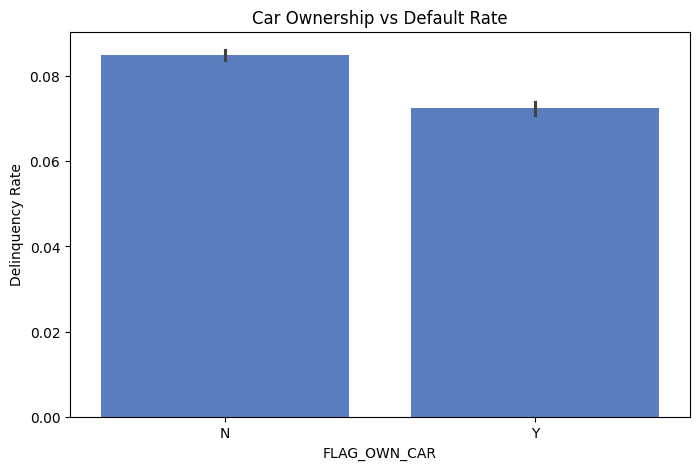

In [ ]:
# 차량 보유 여부에 따른 연체율(TARGET) 비교
plt.figure(figsize=(8, 5))
sns.barplot(x='FLAG_OWN_CAR', y='TARGET', data=df)
plt.title('Car Ownership vs Default Rate')
plt.ylabel('Delinquency Rate')
plt.show()

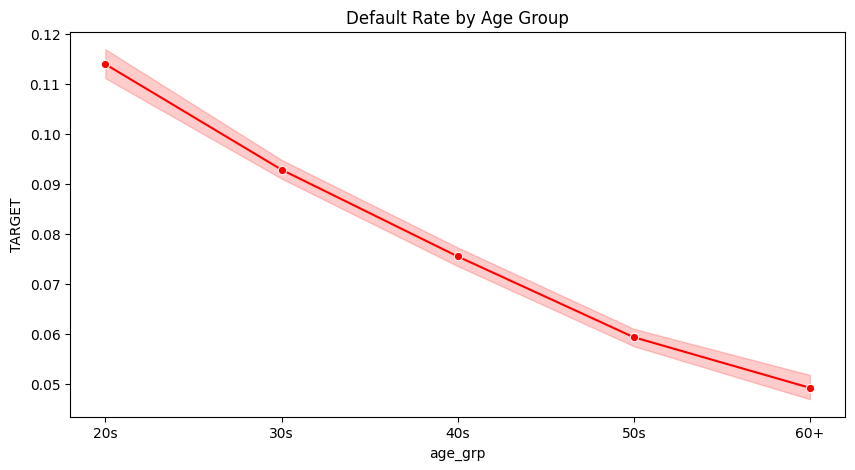

/tmp/ipykernel_55/1475322094.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dti_grp', y='TARGET', data=df, palette='Reds')


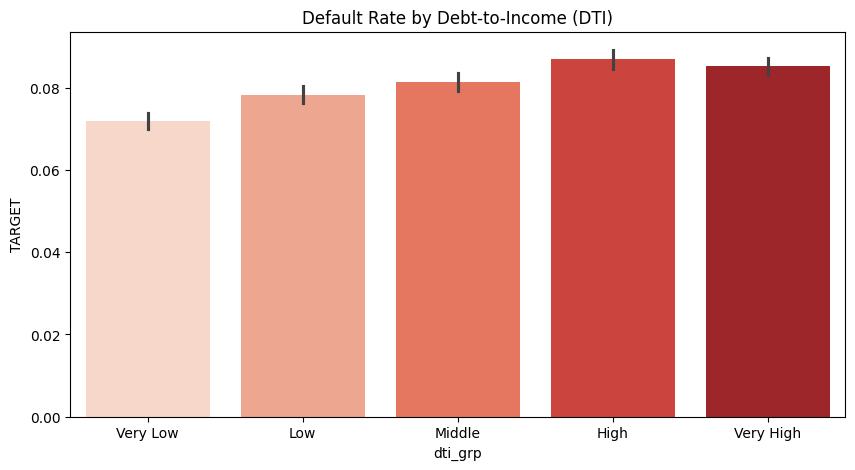

In [ ]:
# 1. 연령대별 연체율 시각화
df['age_grp'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 60, 100], labels=['20s', '30s', '40s', '50s', '60+'])
plt.figure(figsize=(10, 5))
sns.lineplot(x='age_grp', y='TARGET', data=df, marker='o', color='red')
plt.title('Default Rate by Age Group')
plt.show()

# 2. DTI(상환부담) 구간별 연체율 분석
df['dti_grp'] = pd.qcut(df['dti'], 5, labels=['Very Low', 'Low', 'Middle', 'High', 'Very High'])
plt.figure(figsize=(10, 5))
sns.barplot(x='dti_grp', y='TARGET', data=df, palette='Reds')
plt.title('Default Rate by Debt-to-Income (DTI)')
plt.show()

In [ ]:
# 1. 먼저 merge를 진행 (fillna는 여기서 뺍니다)
df_eda = pd.merge(df, bureau_ovd[['SK_ID_CURR', 'has_outer_overdue']], on='SK_ID_CURR', how='left')

# 2. 결측치를 0으로 채워야 하는 '수치형' 컬럼들만 리스트로 지정
# (필요한 컬럼들을 계속 추가하세요)
num_cols = ['has_outer_overdue', 'avg_delay', 'max_delay', 'pay_count', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY']

# 3. 존재하는 컬럼에 대해서만 수치형 결측치 처리
for col in num_cols:
    if col in df_eda.columns:
        df_eda[col] = df_eda[col].fillna(0)

print("수치형 데이터 결측치 처리 완료!")

NameError: name 'bureau_ovd' is not defined

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.barplot(x='has_outer_overdue', y='TARGET', data=df_eda)
plt.title('Impact of External Overdue')
plt.xlabel('Has Outer Overdue (0: No, 1: Yes)')
plt.ylabel('Default Rate (TARGET)')
plt.show()

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 'Y'는 1로, 'N'은 0으로 변환
df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})

# 1. 학습용 변수 선정
features = ['AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'age', 'dti', 'avg_delay', 'max_delay', 'FLAG_OWN_CAR']
X = df[features]
y = df['TARGET']

# 2. 데이터 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 모델 생성 및 학습
model = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# 4. 성능 확인 (AUC 점수 - 0.7 이상이면 실무급)
y_pred_proba = model.predict_proba(X_test)[:, 1]
print(f"모델 연체 예측 성능(AUC): {roc_auc_score(y_test, y_pred_proba):.4f}")